In [25]:
# Import the libraries needed for data loading, visualization, and imbalanced-data resampling.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Load the diabetes dataset from the local folder into a pandas DataFrame.
df = pd.read_csv("diabetes_data/diabetic_data.csv")

In [27]:
# Inspect the available column names to understand the dataset structure.
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='str')

In [28]:
# Preview the first few rows to confirm the data looks correct.
df.head(3)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


In [29]:
# Check the unique labels in the target column before handling class imbalance.
df['readmitted'].unique()

<StringArray>
['NO', '>30', '<30']
Length: 3, dtype: str

```bash
<30 → Patient was readmitted within 30 days of discharge.
🔹 Most critical (often hospitals are penalized if this happens).

>30 → Patient was readmitted, but only after 30 days.
🔹 Important, but less severe.

NO → Patient was not readmitted at all.
🔹 Majority class in this dataset.
```

In [30]:
# Define a helper function to compare the original class distribution with a resampled one.
def plot_class_distribution(y_old, y_new, title):

    category_order = ['NO', '>30', '<30']
    display_labels = ['NO', '>30 days', '<30 days']

    # Create a side-by-side figure with two plots.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(title, fontsize=16)

    # Plot the original class counts on the left.
    sns.countplot(x=y_old, ax=ax1, order=category_order)
    ax1.set_title('Original Distribution')
    ax1.set_xlabel('Readmission Category')
    ax1.set_ylabel('Count')
    ax1.set_xticks(display_labels)
    
    # Plot the resampled class counts on the right.
    sns.countplot(x=y_new, ax=ax2, order=category_order)
    ax2.set_title('Resampled Distribution')
    ax2.set_xlabel('Readmission Category')
    ax2.set_ylabel('Count')
    ax2.set_xticks(display_labels)
    
    # Improve spacing so the titles and labels fit nicely.
    # plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [31]:
# Define a helper function to compare four distributions at once: original, RUS-not-majority, RUS-majority, and RUS-all.
def plot_class_distribution_4(y1, y2, y3, y4, title):
    # Define the data order and display labels to ensure proper alignment.
    category_order = ['NO', '>30', '<30']
    display_labels = ['NO', '>30 days', '<30 days']
    
    # Create four side-by-side subplots for comparison.
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 8))
    fig.suptitle(title, fontsize=16)

    # Plot the original distribution in the first panel with explicit order.
    sns.countplot(x=y1, ax=ax1, order=category_order)
    ax1.set_title('Original Distribution')
    ax1.set_xlabel('Readmission Category')
    ax1.set_ylabel('Count')
    ax1.set_xticklabels(display_labels)
    
    # Plot the under-sampled distribution where the majority class is reduced.
    sns.countplot(x=y2, ax=ax2, order=category_order)
    ax2.set_title('Resampled Distribution (not majority)')
    ax2.set_xlabel('Readmission Category')
    ax2.set_ylabel('Count')
    ax2.set_xticklabels(display_labels)

    # Plot the under-sampled distribution where the majority class is targeted explicitly.
    sns.countplot(x=y3, ax=ax3, order=category_order)
    ax3.set_title('Resampled Distribution (majority)')
    ax3.set_xlabel('Readmission Category')
    ax3.set_ylabel('Count')
    ax3.set_xticklabels(display_labels)

    # Plot the under-sampled distribution after balancing all classes.
    sns.countplot(x=y4, ax=ax4, order=category_order)
    ax4.set_title('Resampled Distribution (all)')
    ax4.set_xlabel('Readmission Category')
    ax4.set_ylabel('Count')
    ax4.set_xticklabels(display_labels)
    
    # Improve layout to make all plots readable.
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# These comments show the expected class counts for each resampling strategy.
# Original distribution: Counter({'NO': 54864, '>30': 35545, '<30': 11357})
# Under-sampling distribution (not majority): Counter({'NO': 54864, '>30': 11357, '<30': 11357}), make all classes equal to the minority class count (11357) except for the majority class (NO) which remains at its original count.
# Under-sampling distribution (majority): Counter({'NO': 11357,'>30': 35545, '<30': 11357, }), make only majority class (NO) equal to the minority class count (11357), while keeping the other classes at their original counts.
# Under-sampling distribution (all): Counter({'NO': 11357, '>30': 11357, '<30': 11357, }), make all classes equal to the minority class count (11357).

In [32]:
# Separate the feature matrix X from the target label y.
# We drop the target column and ID-like columns because they are not useful for modeling.
X = df.drop(columns=['readmitted', 'encounter_id', 'patient_nbr'], errors='ignore')
y = df['readmitted']

In [33]:
# Inspect the data types and missing values in the feature matrix.
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   race                      101766 non-null  str  
 1   gender                    101766 non-null  str  
 2   age                       101766 non-null  str  
 3   weight                    101766 non-null  str  
 4   admission_type_id         101766 non-null  int64
 5   discharge_disposition_id  101766 non-null  int64
 6   admission_source_id       101766 non-null  int64
 7   time_in_hospital          101766 non-null  int64
 8   payer_code                101766 non-null  str  
 9   medical_specialty         101766 non-null  str  
 10  num_lab_procedures        101766 non-null  int64
 11  num_procedures            101766 non-null  int64
 12  num_medications           101766 non-null  int64
 13  number_outpatient         101766 non-null  int64
 14  number_emergency          10176

In [34]:
# Convert categorical features into numeric dummy variables so resampling methods like SMOTE can work.
X = pd.get_dummies(X)

In [35]:
# Uncomment this line if the imbalanced-learn package is not installed in your environment.
# !pip install imblearn

In [36]:
# Import the resampling techniques used to handle class imbalance.
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

In [37]:
# Create three random under-sampling strategies with different rules for the majority class.
# 1) 'not majority' keeps all minority classes and reduces the majority class.
# 2) 'majority' reduces the majority class specifically.
# 3) 'all' balances all classes to the same size.
rus = RandomUnderSampler(sampling_strategy='not majority', random_state=1)
rus_majority = RandomUnderSampler(sampling_strategy='majority', random_state=1)
rus_all = RandomUnderSampler(sampling_strategy='all', random_state=1)


In [38]:
# Import Counter to easily print the class distribution after each resampling step.
from collections import Counter

In [39]:
# Apply each under-sampling strategy to the features and target labels.
X_rus, y_rus = rus.fit_resample(X, y)
X_rus_maj, y_rus_maj = rus_majority.fit_resample(X, y)
X_rus_all, y_rus_all = rus_all.fit_resample(X, y)

In [42]:
X_rus.shape

(77578, 2468)

In [43]:
y_rus.shape

(77578,)

In [44]:
X.shape

(101766, 2468)

In [45]:
y.shape

(101766,)

In [46]:
# Print the class distribution before and after the under-sampling methods for comparison.
print("Original distribution:", Counter(y))
print("Under-sampling distribution (not majority):", Counter(y_rus))
print("Under-sampling distribution (majority):", Counter(y_rus_maj))
print("Under-sampling distribution (all):", Counter(y_rus_all))

Original distribution: Counter({'NO': 54864, '>30': 35545, '<30': 11357})
Under-sampling distribution (not majority): Counter({'NO': 54864, '<30': 11357, '>30': 11357})
Under-sampling distribution (majority): Counter({'>30': 35545, '<30': 11357, 'NO': 11357})
Under-sampling distribution (all): Counter({'<30': 11357, '>30': 11357, 'NO': 11357})


In [47]:
y_rus

81843     <30
95312     <30
54106     <30
18951     <30
53450     <30
         ... 
101759     NO
101762     NO
101763     NO
101764     NO
101765     NO
Name: readmitted, Length: 77578, dtype: str

C:\Users\abhis\AppData\Local\Temp\ipykernel_23516\941966727.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(display_labels)
C:\Users\abhis\AppData\Local\Temp\ipykernel_23516\941966727.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(display_labels)
C:\Users\abhis\AppData\Local\Temp\ipykernel_23516\941966727.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(display_labels)
C:\Users\abhis\AppData\Local\Temp\ipykernel_23516\941966727.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(display_labels)


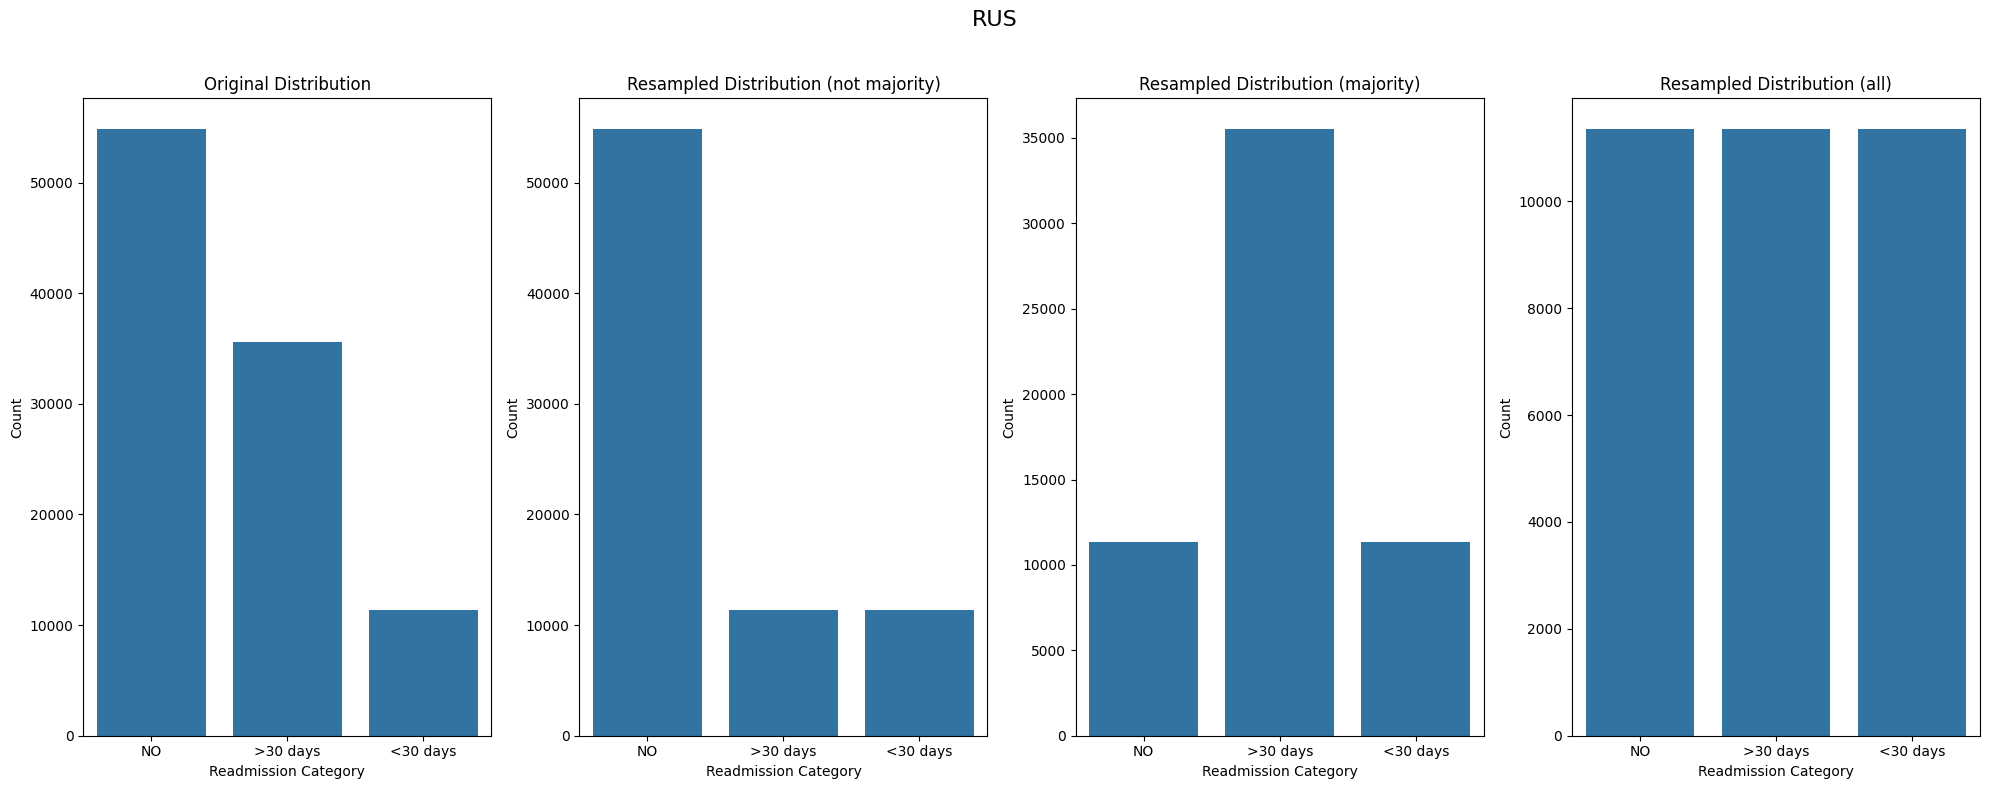

In [48]:
# Visualize the original and under-sampled distributions side by side.
plot_class_distribution_4(y, y_rus, y_rus_maj, y_rus_all, "RUS")

Let's move on to **Random Over-Sampling (ROS)**. This is the exact flip side of the coin. Instead of putting the majority class on a diet, we are force-feeding the minority class to make it match the majority.

Here is the breakdown of how it works, the mechanics, the pros and cons, and what to watch out for.

## What is Random Over-Sampling?

In an imbalanced dataset, the minority class doesn't have enough examples for the model to learn its patterns effectively.

Random Over-Sampling balances the dataset by randomly selecting existing examples from the minority class and **duplicating** them (with replacement) until the minority class matches the size of the majority class (or a target ratio).

## The Stats & Mechanics Behind It

Unlike under-sampling, ROS does not throw away data. Instead, it alters the dataset through **uniform random sampling with replacement** from the minority class population.

- **Class Distribution Shift:** Similar to under-sampling, ROS changes the prior probability $P(Y)$ so that in a fully balanced set, $P(Y_{majority}) = P(Y_{minority}) = 0.5$.
- **Effect on Data Variance:** Because you are duplicating exact data points, you are not introducing any new information or expanding the variance of the minority class. Geometrically, you are placing multiple identical data points on top of each other in the feature space.
- **The Weighting Effect:** Statistically, duplicating a data point $k$ times is mathematically equivalent to giving that specific data point $k$ times more weight in the model's cost/loss function. The model is heavily penalized if it misclassifies these duplicated points.

## Pros & Cons

### The Good (Pros)

- **Zero Information Loss:** Unlike under-sampling, you keep every single bit of information from the majority class. No useful patterns are discarded.
- **Simple to Implement:** It requires no complex geometric math or distance metrics (unlike SMOTE), making it computationally simple to execute.
- **Better Component Extraction:** It forces the machine learning algorithm to pay attention to the minority class by amplifying its presence.

### The Bad (Cons)

- **Severe Risk of Overfitting:** This is the biggest flaw of ROS. Because the model sees the exact same minority examples multiple times, it doesn't learn a *generalized* rule for the minority class. Instead, it memorizes the specific training examples, leading to high training accuracy but poor generalization on unseen data.
- **Increased Computational Cost:** You are increasing the size of your dataset (sometimes drastically). If you have 1 million majority rows and 1,000 minority rows, ROS will duplicate those 1,000 rows until you have a total dataset of 2 million rows. This increases training time and memory usage.

## When to Use It

ROS is highly effective under these conditions:

1. **Small or Moderate Datasets:** If your overall dataset is small, you cannot afford to throw data away using under-sampling. Over-sampling ensures you keep what little data you have.
2. **When Information Retention is Critical:** If the majority class contains complex, intricate decision boundaries that would be ruined if you deleted rows.
3. **As a Baseline:** It serves as a great, quick benchmark to see if over-sampling helps before moving on to more complex synthetic techniques like SMOTE.

## Pitfalls to Avoid

- **The "Data Leakage" Disaster (Crucial):** Just like under-sampling, **you must split your data into Train/Test BEFORE over-sampling.** If you over-sample the entire dataset first and then split it, the exact same duplicated rows will end up in both the training set and the testing set. Your model will perfectly "predict" the test data because it already memorized it in training, giving you fake, overly optimistic evaluation metrics.
- **Blinded by Training Metrics:** Because of the duplication, tree-based models (like Random Forests or Gradient Boosting) can easily create specific rules for those duplicated points, driving training error to near zero while failing in production. Always trust your cross-validation on *non-oversampled* folds.

## Summary

**Random Over-Sampling** balances datasets by duplicating minority class instances. Its main advantage is that it **preserves all original information**, making it great for smaller datasets. However, because it relies on exact replication rather than creating new variations, its fatal flaw is a **heavy tendency to overfit** the minority class while significantly increasing computational and memory costs.


In [49]:
# Random Over-sampling increases the minority class samples to reduce imbalance.
# This approach duplicates minority-class rows rather than generating new synthetic data.
ros = RandomOverSampler(sampling_strategy='not majority', random_state=1)
X_ros, y_ros = ros.fit_resample(X, y)
print("Original distribution:", Counter(y))
print("Over-sampling distribution:", Counter(y_ros))


Original distribution: Counter({'NO': 54864, '>30': 35545, '<30': 11357})
Over-sampling distribution: Counter({'NO': 54864, '>30': 54864, '<30': 54864})


In [ ]:
plot_class_distribution(y, y_ros, "Random Over-sampling (not majority)")

In [51]:
print("Original X shape:", X.shape)
print("Original y shape:", y.shape)
print("Over-sampled X shape:", X_ros.shape)
print("Over-sampled y shape:", y_ros.shape)

# All features and target are sampled as part of imbalane handling

Original X shape: (101766, 2468)
Original y shape: (101766,)
Over-sampled X shape: (164592, 2468)
Over-sampled y shape: (164592,)


Let's move on to **SMOTE (Synthetic Minority Over-sampling Technique)**.

SMOTE was invented to solve the exact flaw we just discussed with Random Over-Sampling: **overfitting due to data duplication**. Instead of making exact copies of the minority class, SMOTE acts like an artist, drawing lines between existing minority points and creating brand-new, synthetic variations along those lines.

Here is the breakdown of how SMOTE works, its mathematical logic, the pros and cons, and the pitfalls to watch out for.

## What is SMOTE?

SMOTE balances the dataset by creating **synthetic (made-up) examples** of the minority class.

Instead of duplicating data, it looks at the feature space of the minority class, identifies data points that are close to each other, and generates new data points somewhere in the space between them. This forces the model to learn a broader, more generalized decision boundary rather than memorizing specific points.

## The Stats & Mechanics Behind It

SMOTE relies heavily on geometry and the **$k$-Nearest Neighbors ($k$-NN)** algorithm. Here is the exact step-by-step math it uses to create a new data point:

1. **Select a Core Point:** The algorithm picks a random minority class sample, let's call it $x_i$.
2. **Find the Neighbors:** It identifies the $k$-nearest neighbors of $x_i$ that *also* belong to the **minority class** (usually $k=5$).
3. **Choose a Neighbor:** It randomly selects one of these $k$ neighbors, let's call it $x_{zi}$.
4. **Create the Vector:** It calculates the distance vector between the two points: $(x_{zi} - x_i)$.
5. **Generate the Synthetic Point:** It multiplies this vector by a random number $\lambda$ between 0 and 1, and adds it to the original point:

$$
x_{new} = x_i + \lambda \times (x_{zi} - x_i)
$$

Geometrically, $x_{new}$ is guaranteed to lie on the straight line segment connecting $x_i$ and $x_{zi}$.

## Pros & Cons

### The Good (Pros)

- **Mitigates Overfitting:** By creating new, distinct data points rather than repeating old ones, it introduces variance. The model learns the *region* of the minority class rather than specific coordinates, leading to better generalization.
- **Preserves Majority Information:** Like ROS, it doesn't throw away any information from the majority class.
- **Widely Adopted and Supported:** It is the industry standard for synthetic over-sampling, meaning it is natively supported in almost every machine learning library (like `imbalanced-learn`).

### The Bad (Cons)

- **The "Class Overlap" Problem (Blindness to Majority):** SMOTE *only* looks at minority neighbors when creating new points. If a minority point happens to be an outlier sitting deep inside the majority class cluster, SMOTE will blindly draw a line between it and another minority point, creating synthetic minority data right in the middle of the majority class. This increases class overlap and confuses the model.
- **Ineffective for High-Dimensional Data:** If your data has hundreds of features, the concept of "distance" breaks down (known as the Curse of Dimensionality). $k$-NN struggles to find meaningful neighbors, causing SMOTE to create noisy, unrealistic data.
- **Higher Computational Complexity:** Unlike the random methods, SMOTE has to compute Euclidean distances for every minority point, making it significantly slower on large datasets.

## When to Use It

SMOTE shines under these conditions:

1. **Low-to-Medium Dimensionality:** When your dataset has a reasonable number of continuous/numeric features (e.g., less than 50-100 features).
2. **Continuous Features:** SMOTE relies on distance metrics. It works best when features are continuous (like income, age, blood pressure). *Note: Standard SMOTE struggles with categorical variables; you need a variant called SMOTE-NC for that.*
3. **Distinct but Sparse Minority Class:** When the minority class points are grouped together but just sparse, allowing SMOTE to fill in the blanks safely.

## Pitfalls to Avoid

- **The Validation Leakage (Still Applies!):** We cannot stress this enough—**only SMOTE your training data.** If you SMOTE the validation/test set, your model will be evaluated on artificial data, completely invalidating your test results.
- **Creating "Ghost" Data in the Majority Domain:** Always look at your feature distributions or a T-SNE/PCA plot after applying SMOTE. If you see synthetic minority points aggressively invading majority class territory, you may need to use clean-up variants like **SMOTE-Tomek** or **SMOTE-ENN**, which delete noisy overlapping points after SMOTE runs.

## Summary

**SMOTE** resolves the overfitting issues of random over-sampling by using a $k$-nearest neighbors approach to **create entirely new, synthetic data points** along the lines connecting existing minority samples. While it vastly improves generalization, its fatal flaw is its **blindness to the majority class**, which can lead to creating artificial data in overlapping or noisy regions, potentially muddying the decision boundary.

This "blindness to the majority class" is SMOTE's Achilles' heel. It happens because standard SMOTE only looks at **minority-to-minority** connections when creating new data points, completely ignoring whether a massive cluster of majority points lies right in between them.

Let’s walk through a practical, real-world example to see exactly how this ruins a model.

## The Scenario: Credit Card Fraud

Imagine you are building a fraud detection model. You have two features:

1. **Transaction Amount**
2. **Distance from Home** (where the transaction occurred)

### The Normal State (Real World)

- **Majority Class (Legitimate - Blue):** Thousands of transactions. They cluster tightly together: low-to-medium amounts, close to home.
- **Minority Class (Fraudulent - Red):** Very few transactions. Mostly high amounts, far away.

However, real data is noisy. You have **one legitimate transaction** (Blue) that happens to be an outlier—say, a user went on a sudden vacation and made a massive purchase. Right next to it is a **single fraudulent transaction** (Red) that happened to be a smaller amount, closer to home.

In your feature space, these two data points are sitting very close to one another, right in the "border zone" between normal and fraud.

## What SMOTE Does (The Mistake)

Because SMOTE only looks at the minority class (Red) to find $k$-nearest neighbors:

1. It selects that outlier fraud point (Red) near the border.
2. It finds its nearest fraud neighbor, which happens to be a high-amount, far-from-home fraud point further out.(which can be blue point)
3. **It draws a straight line between them and creates 5 new synthetic "Fraud" points.**

Because it ignored the blue (legitimate) cluster entirely, SMOTE just generated fake "Fraud" points **right on top of or directly inside** the cluster of legitimate transactions.

## The Consequence: A "Muddied" Decision Boundary

Because SMOTE has now littered the legitimate (Blue) cluster with fake "Fraud" (Red) points, the decision boundary of your machine learning model becomes highly distorted:

- **Before SMOTE:** The model had a clean, simple line separating the normal zone from the high-risk zone.
- **After SMOTE:** To avoid misclassifying the newly generated fake points, the model is forced to bend, twist, and create highly complex, jagged boundaries. It starts believing that normal, everyday purchases are actually fraudulent.

### The Real-World Impact

Your business metrics suffer:

- **False Positives Skyrocket:** Legitimate customers suddenly have their cards blocked for normal transactions because your model's decision boundary has been "muddied" and pushed too far into the legitimate zone.
- **Generalization Drops:** The model overfits to the noisy synthetic points, making it perform poorly on real, unseen production data.

## How this is Solved in Practice

Data scientists rarely use raw, basic SMOTE on noisy data because of this flaw. Instead, they use two popular adjustments:

1. **Borderline-SMOTE:** It only creates synthetic points along the border *if* the minority points are not entirely surrounded by the majority class. If a point is heavily engulfed by the majority class (an outlier), it is ignored.
2. **SMOTE + Tomek Links:** This is a two-step process. First, SMOTE creates the synthetic data. Second, the algorithm finds "Tomek Links"—pairs of opposite-class points that are extremely close to each other—and **deletes them**. This clean-up phase effectively "shaves" away the overlapping noise, leaving a clean, wide gap between the two classes.

Let’s build a concrete, step-by-step mathematical and geometric walkthrough of the **Credit Card Fraud** scenario.

We will trace exactly how a single noisy outlier causes SMOTE to construct a bridge of artificial fraud data right through a cluster of completely legitimate transactions, ultimately breaking our model's decision boundary.

## Step 1: The Initial Dataset (The Setup)

Imagine we are tracking two features for credit card transactions:

- **$X_1$ (Distance from Home):** Scaled from 0 to 10 (higher means further away).
- **$X_2$ (Transaction Amount):** Scaled from 0 to 10 (higher means more expensive).

Let’s look at our training data points:

### The Legitimate Transactions (Majority Class: Blue)

Legitimate transactions cluster tightly in the low-distance, low-to-medium amount region.

- $M_1 = (1.0, 1.0)$
- $M_2 = (1.5, 2.0)$
- $M_3 = (2.0, 1.5)$
- $M_4 = (2.5, 2.5)$ — *This is a legitimate travel purchase (noisy outlier sitting further out).*

### The Fraudulent Transactions (Minority Class: Red)

Fraudulent transactions are sparse and sit mostly in the high-distance, high-amount region.

- $F_1 = (8.0, 9.0)$ (High distance, high amount)
- $F_2 = (1.2, 3.0)$ — *This is an outlier fraud case (a small, local fraudulent purchase sitting very close to the legitimate cluster).*

## Step 2: Finding $k$-Nearest Neighbors (The Blind Spot)

Now we run SMOTE with $k=1$ (for mathematical simplicity, searching for the 1 nearest neighbor) to generate new synthetic fraud points.

SMOTE’s algorithm **only** looks at the minority class (Red points: $F_1$ and $F_2$). It completely ignores the Blue points.

1. The algorithm selects the outlier fraud point **$F_2 = (1.2, 3.0)$**.
2. It calculates the Euclidean distance from $F_2$ to all other fraud points to find its nearest neighbor.
3. Since there is only one other fraud point, its nearest neighbor is **$F_1 = (8.0, 9.0)$**.

> **The Blindness in Action:** Even though the legitimate travel purchase $M_4 = (2.5, 2.5)$ is physically much closer to $F_2$ than $F_1$ is, SMOTE completely ignores $M_4$ because it belongs to the majority class.
>
>

## Step 3: Generating Synthetic Points (The Linear Bridge)

SMOTE now creates a synthetic point ($F_{synth}$) along the straight line connecting $F_2$ and $F_1$.

Using the SMOTE formula:

$$
F_{synth} = F_2 + \lambda \times (F_1 - F_2)
$$

Let’s say the random number generator picks $\lambda = 0.2$ (meaning the synthetic point will be created 20% of the way along the path from $F_2$ to $F_1$):

$$
F_{synth} = (1.2, 3.0) + 0.2 \times \big((8.0, 9.0) - (1.2, 3.0)\big)
$$

$$
F_{synth} = (1.2, 3.0) + 0.2 \times (6.8, 6.0)
$$

$$
F_{synth} = (1.2, 3.0) + (1.36, 1.2)
$$

$$
F_{synth} = (2.56, 4.2)
$$

Let's do it again with a few more random values of $\lambda$ to generate a small cluster of points:

- For $\lambda = 0.1 \implies F_{synth2} = (1.88, 3.6)$
- For $\lambda = 0.3 \implies F_{synth3} = (3.24, 4.8)$

## Step 4: The Blurred Decision Boundary

Now let’s look at what our feature space looks like after SMOTE has finished.

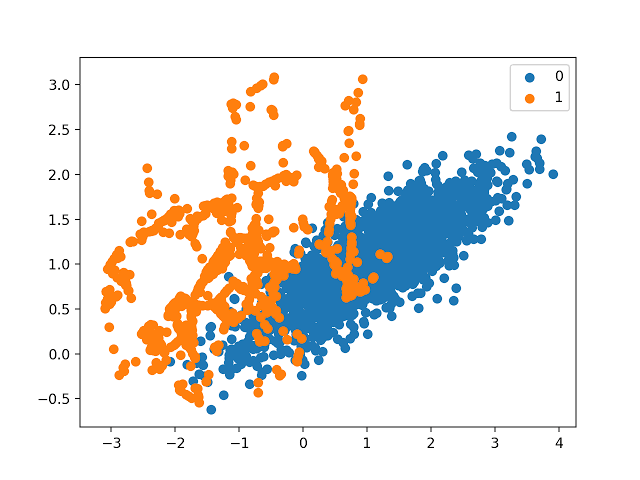

SMOTE creating synthetic points directly overlapping the majority class. Source: Machine Learning Mastery

### The Geometric Intrusion

Look closely at the coordinates of our newly created synthetic "fraud" points compared to our legitimate points:

- The legitimate travel outlier $M_4$ sits at $(2.5, 2.5)$.
- Our synthetic fraud point $F_{synth}$ is placed at $(2.56, 4.2)$.
- Our synthetic fraud point $F_{synth2}$ is placed at $(1.88, 3.6)$.

Because SMOTE blindly drew a line from the deep-country fraud outlier ($F_1$) to the local-fraud outlier ($F_2$), **it has literally paved a road of synthetic fraud points right through the heart of the legitimate transaction zone.**

### What the Machine Learning Model Sees

When a classification model (like a Decision Tree or SVM) tries to draw a boundary:

1. **Without SMOTE:** The model sees a clear cluster of legitimate transactions in the bottom-left and a few sparse fraud points. It draws a clean, simple diagonal boundary line. The occasional outlier $F_2$ might be misclassified as legitimate, but the overall system remains highly stable.
2. **With SMOTE:** The model is suddenly presented with multiple "fraud" points ($F_{synth}$, $F_{synth2}$, $F_{synth3}$) sitting right next to and above the legitimate cluster. To achieve high training accuracy, the model's decision boundary is forced to **aggressively warp and bend downward**, carving out a jagged pocket to isolate these synthetic points.

### The Real-World Failure

Because the boundary has been pushed deep into legitimate territory, the next time a regular customer goes on a weekend trip and makes a slightly higher purchase (e.g., at coordinates $2.3, 3.8$):

- **The model flags it as Fraud.**
- The transaction is blocked.
- The customer is frustrated by a false positive, all because SMOTE invented "fake" fraud points in a region where real fraud has never actually occurred.

In [52]:
# SMOTE creates synthetic samples for the minority class instead of simply duplicating rows.
smote = SMOTE(sampling_strategy='not majority', random_state=1)
X_sm, y_sm = smote.fit_resample(X, y)
print("Original distribution:", Counter(y))
print("SMOTE distribution:", Counter(y_sm))
print("SMOTE feature distribution:", Counter(X_sm))

Original distribution: Counter({'NO': 54864, '>30': 35545, '<30': 11357})
SMOTE distribution: Counter({'NO': 54864, '>30': 54864, '<30': 54864})
SMOTE feature distribution: Counter({'admission_type_id': 1, 'discharge_disposition_id': 1, 'admission_source_id': 1, 'time_in_hospital': 1, 'num_lab_procedures': 1, 'num_procedures': 1, 'num_medications': 1, 'number_outpatient': 1, 'number_emergency': 1, 'number_inpatient': 1, 'number_diagnoses': 1, 'race_?': 1, 'race_AfricanAmerican': 1, 'race_Asian': 1, 'race_Caucasian': 1, 'race_Hispanic': 1, 'race_Other': 1, 'gender_Female': 1, 'gender_Male': 1, 'gender_Unknown/Invalid': 1, 'age_[0-10)': 1, 'age_[10-20)': 1, 'age_[20-30)': 1, 'age_[30-40)': 1, 'age_[40-50)': 1, 'age_[50-60)': 1, 'age_[60-70)': 1, 'age_[70-80)': 1, 'age_[80-90)': 1, 'age_[90-100)': 1, 'weight_>200': 1, 'weight_?': 1, 'weight_[0-25)': 1, 'weight_[100-125)': 1, 'weight_[125-150)': 1, 'weight_[150-175)': 1, 'weight_[175-200)': 1, 'weight_[25-50)': 1, 'weight_[50-75)': 1, 'wei

**ADASYN (Adaptive Synthetic Sampling Approach)**.

ADASYN was designed as a direct, highly intelligent evolution of SMOTE. Where SMOTE is democratic (treating all minority points equally), ADASYN is **merit-based**. It specifically identifies which minority points are the hardest to learn because they are surrounded by the majority class, and focuses its synthetic-data-creation efforts almost entirely on them.

Here is the breakdown of ADASYN, its mathematical logic, the pros and cons, and how to use it safely.

## What is ADASYN?

ADASYN balances datasets by creating synthetic minority class examples, but with a twist: **it dynamically decides how many synthetic points to generate for each minority instance.**

If a minority data point is sitting comfortably in a safe cluster of other minority points, ADASYN leaves it alone. But if a minority point is struggling, deeply surrounded by majority class points (making it highly likely to be misclassified), ADASYN targets it as a "hard-to-learn" point and creates a high density of synthetic data around it.

## The Stats & Mechanics Behind It

ADASYN uses a beautiful, probability-based distribution to determine where to generate data. Here is the exact mathematical walkthrough:

### Step 1: Calculate the Total Synthetic Points Needed

First, we determine how many total synthetic data points $N_y$ we need to generate to reach our target balance:

$$
N_y = (N_{maj} - N_{min}) \times \beta
$$

*(where $\beta \in [0, 1]$ is the target balance ratio. If $\beta = 1.0$, we want perfect $50:50$ balance).*

### Step 2: Calculate the Difficulty Ratio for Each Minority Point

For every individual minority point $x_i$, we find its $k$-nearest neighbors (looking at *both* majority and minority classes). We then calculate its **difficulty ratio** $r_i$:

$$
r_i = \frac{\Delta_i}{k}
$$

*(where $\Delta_i$ is the number of those $k$ neighbors that belong to the **majority class**).*

- If $r_i = 0$, the point is entirely surrounded by its own kind (easy to learn).
- If $r_i = 1.0$, the point is entirely engulfed by the majority class (very hard to learn).

### Step 3: Normalize to Create a Probability Distribution

We normalize these difficulty ratios so they sum to 1, creating a density distribution $\hat{r}_i$:

$$
\hat{r}_i = \frac{r_i}{\sum r_i}
$$

### Step 4: Determine Synthetic Points Per Instance

Now, we calculate exactly how many synthetic points $g_i$ to generate for each original minority point $x_i$:

$$
g_i = \hat{r}_i \times N_y
$$

### Step 5: Generate the Data

For each $x_i$, we generate $g_i$ synthetic points using the exact same linear interpolation math as SMOTE (picking a random minority neighbor and drawing a point along the connecting vector).

## Pros & Cons

### The Good (Pros)

- **Learns the Hard Boundaries:** By focusing heavily on the "border zone" where the classes overlap, ADASYN forces the machine learning model to pay extra attention to the exact areas where it is most likely to make mistakes.
- **Highly Adaptive:** It doesn't waste computational power or memory generating synthetic points in "easy" regions where the model already has clear, unambiguous paths to make a correct prediction.
- **Reduces Bias:** It directly addresses the decision boundary bias that standard SMOTE often ignores.

### The Bad (Cons)

- **Highly Sensitive to Outliers (The "Noise Trap"):** Because ADASYN focuses heavily on minority points surrounded by the majority class, **it can easily get tricked by noise**. If a minority point is actually just a random outlier (an error in the data) sitting deep in majority territory, ADASYN will aggressively generate hundreds of synthetic points around it, turning a single error into a massive, artificial cluster of fake data.
- **Higher Variance in Decision Boundaries:** Because it shifts the focus to the most chaotic regions of your feature space, the resulting decision boundaries can sometimes become highly complex, jagged, or unstable.
- **Computational Complexity:** Calculating the $k$-NN step across both classes and normalizing the distribution makes ADASYN computationally heavier than SMOTE.

## When to Use It

ADASYN is the ideal choice when:

1. **The Decision Boundary is Complex:** When the boundary between your classes isn't a clean, straight line, and you need the model to learn subtle, complex transition zones.
2. **Noisy Data Has Been Cleared:** ADASYN works beautifully if you have already cleaned your dataset of extreme outliers and noise before running the sampler.
3. **Standard SMOTE Underperforms:** If you tried SMOTE and found the model was still heavily misclassifying boundary cases, ADASYN is the logical next upgrade.

## Pitfalls to Avoid

- **The Outlier Amplification Pitfall:** Because of its math, ADASYN *loves* outliers. If you do not clean your dataset first, it will synthesize data around errors. Always run an outlier detection/removal step (like Isolation Forests or Z-score filtering) on your training set *before* applying ADASYN.
- **Over-focusing on the Impossible:** Sometimes, a minority point is surrounded by majority points because it is simply impossible to classify correctly using the current features. Forcing ADASYN to build a massive cluster of data around an unclassifiable point will only degrade your model's overall performance.

## Summary

**ADASYN** is an adaptive, smart over-sampler that **targets the hardest-to-learn minority points** by looking at how heavily surrounded they are by the majority class. It generates more synthetic data in chaotic, overlapping border zones to help models build sharper decision boundaries. However, because of this aggressive focus, its primary danger is **amplifying noise and outliers**, which can ruin model generalization if the dataset isn't carefully pre-cleaned.

## The Ultimate Comparison: Let's Put It All Together

To help lock this in, here is how the four techniques compare side-by-side:

| Technique | Core Mechanism | Primary Benefit | Biggest Risk | Computational Speed |
| --- | --- | --- | --- | --- |
| **Random Under-Sampler** | Deletes random majority rows | Blazing fast; reduces data scale | Extreme **loss of critical information** | Fastest |
| **Random Over-Sampler** | Duplicates random minority rows | Keeps all original data | Extreme **risk of overfitting** | Fast |
| **SMOTE** | Synthesizes data evenly along minority lines | Better generalization than ROS | **Blindness to majority class** (creates overlap) | Medium |
| **ADASYN** | Synthesizes data near majority borders | Force-learns difficult boundaries | **Amplifies noise and outliers** | Slowest |

Let’s apply **ADASYN** to the exact same credit card fraud scenario.

This walkthrough will show you both the magic of ADASYN and its greatest danger (the "Noise Trap"). Because ADASYN focuses heavily on the hardest areas to learn, we will see it calculate exactly how difficult our boundary is, and then witness how it reacts to our noisy outlier $F_2$.

## Step 1: The Setup & Total Points Needed

We have the same dataset.

- **Majority (Legitimate - Blue):** $M_1(1.0, 1.0)$, $M_2(1.5, 2.0)$, $M_3(2.0, 1.5)$, $M_4(2.5, 2.5)$. ($N_{maj} = 4$)
- **Minority (Fraud - Red):** $F_1(8.0, 9.0)$, $F_2(1.2, 3.0)$. ($N_{min} = 2$)

Let’s say we want a perfectly balanced dataset ($\beta = 1.0$). The total number of synthetic points we need to generate ($N_y$) is:

$$
N_y = (N_{maj} - N_{min}) \times \beta = (4 - 2) \times 1.0 = 2 \text{ synthetic points}
$$

## Step 2: Calculating Difficulty for Each Minority Point

Unlike SMOTE, which would split these 2 points evenly (generating 1 point from $F_1$ and 1 from $F_2$), ADASYN looks at the neighborhood of each point to calculate a **difficulty ratio**.

Let's set our neighborhood parameter to $k = 3$. For each minority point, we look at its 3 nearest neighbors **regardless of their class (checking both Blue and Red)**.

### Neighborhood of $F_1(8.0, 9.0)$ (Deep Fraud Zone)

- Its nearest neighbors in the entire dataset are:
1. $F_2(1.2, 3.0)$ (Distance: $\approx 9.2$)
2. $M_4(2.5, 2.5)$ (Distance: $\approx 8.5$)
3. $M_3(2.0, 1.5)$ (Distance: $\approx 9.6$)
- Among these 3 neighbors, how many belong to the **majority class** (Blue)?
- $M_4$ and $M_3$ are Blue. That is **2 majority neighbors**.
- Difficulty ratio ($r_1$): $$ r_1 = \frac{\Delta_1}{k} = \frac{2}{3} \approx 0.67 $$

### Neighborhood of $F_2(1.2, 3.0)$ (Noisy Border Zone)

- Its nearest neighbors in the entire dataset are:
1. $M_2(1.5, 2.0)$ (Distance: $\approx 1.0$)
2. $M_4(2.5, 2.5)$ (Distance: $\approx 1.4$)
3. $M_1(1.0, 1.0)$ (Distance: $\approx 2.0$)
- Among these 3 neighbors, how many belong to the **majority class** (Blue)?
- All 3 ($M_2, M_4, M_1$) are Blue. That is **3 majority neighbors**.
- Difficulty ratio ($r_2$): $$ r_2 = \frac{\Delta_2}{k} = \frac{3}{3} = 1.0 $$

## Step 3: Distributing the Synthetic Generation

Now we normalize these difficulty ratios to create a probability distribution, which dictates where our 2 new synthetic points will be born.

1. **Sum of difficulties:** $\sum r_i = 0.67 + 1.0 = 1.67$
2. **Normalize $F_1$:** $\hat{r}_1 = \frac{0.67}{1.67} \approx 0.40$
3. **Normalize $F_2$:** $\hat{r}_2 = \frac{1.0}{1.67} \approx 0.60$

Next, we calculate how many of our $N_y = 2$ synthetic points to generate from each origin point ($g_i = \hat{r}_i \times N_y$):

- For $F_1$: $g_1 = 0.40 \times 2 = 0.8 \rightarrow \mathbf{1 \text{ point}}$ *(after rounding)*
- For $F_2$: $g_2 = 0.60 \times 2 = 1.2 \rightarrow \mathbf{1 \text{ point}}$ *(after rounding)*

> **Note on scaling:** If we needed 10 synthetic points instead of 2, ADASYN would generate **6 points** around the hard $F_2$ outlier and only **4 points** around the safer $F_1$.
>
>

## Step 4: Generating the Points & The Outcome

To generate the points, ADASYN relies on the same basic line-drawing interpolation as SMOTE. Because $F_1$ and $F_2$ are each other's only minority neighbors, they must connect to each other.

- **From $F_1$:** It draws a point on the line toward $F_2$.
- **From $F_2$:** It also draws a point on the line toward $F_1$.

The final dataset ends up with synthetic points clustered even closer to $F_2$ because ADASYN recognized that $F_2$ is in a highly hostile, "hard-to-learn" neighborhood.

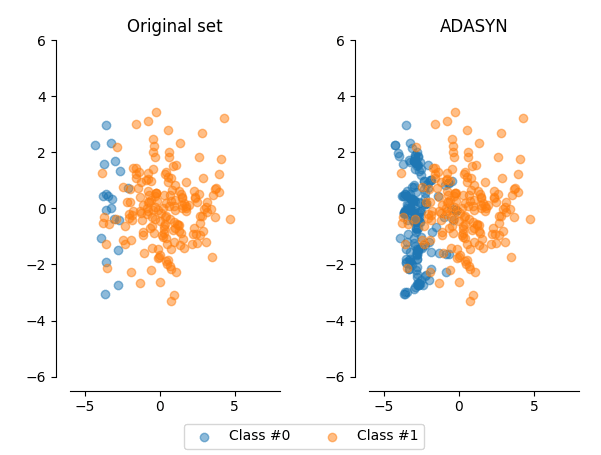

*How ADASYN concentrates synthetic generation directly along the boundary. Source: AI Mind*

## The Verdict: ADASYN vs. SMOTE on this Noise

Did ADASYN fix our blurred boundary problem? **In this specific noisy case, it actually made it worse.**

- **The Intent:** ADASYN correctly identified that the boundary near $F_2$ is incredibly tight and difficult for a classifier to learn.
- **The Failure (The Noise Trap):** Because $F_2$ is actually a noisy outlier (an anomaly rather than a representative trend), ADASYN fell right into the **outlier amplification trap**. It prioritized generating data around $F_2$ because of its high difficulty ratio ($1.0$).
- **The Result:** It heavily populated the overlapping region with synthetic fraud points, aggressively pushing the decision boundary down and creating an even larger "false positive zone" than basic SMOTE did.

### How to actually make ADASYN work here

To make ADASYN succeed in this scenario, you **must run an outlier removal step first**. If we had used a cleaning technique (like Tomek Links or Edited Nearest Neighbors) to delete the noisy outlier $F_2$ before running ADASYN, the algorithm would not have been tricked into over-synthesizing in the legitimate blue cluster.

In [53]:
# ADASYN is similar to SMOTE, but it focuses more on harder-to-classify minority samples.
adasyn = ADASYN(sampling_strategy='not majority', random_state=1)
X_asyn, y_asyn = adasyn.fit_resample(X, y)
print("Original distribution:", Counter(y))
print("ADASYN distribution:", Counter(y_asyn))
print("ADASYN feature distribution:", Counter(X_asyn))

Original distribution: Counter({'NO': 54864, '>30': 35545, '<30': 11357})
ADASYN distribution: Counter({'>30': 60689, 'NO': 54864, '<30': 54431})
ADASYN feature distribution: Counter({'admission_type_id': 1, 'discharge_disposition_id': 1, 'admission_source_id': 1, 'time_in_hospital': 1, 'num_lab_procedures': 1, 'num_procedures': 1, 'num_medications': 1, 'number_outpatient': 1, 'number_emergency': 1, 'number_inpatient': 1, 'number_diagnoses': 1, 'race_?': 1, 'race_AfricanAmerican': 1, 'race_Asian': 1, 'race_Caucasian': 1, 'race_Hispanic': 1, 'race_Other': 1, 'gender_Female': 1, 'gender_Male': 1, 'gender_Unknown/Invalid': 1, 'age_[0-10)': 1, 'age_[10-20)': 1, 'age_[20-30)': 1, 'age_[30-40)': 1, 'age_[40-50)': 1, 'age_[50-60)': 1, 'age_[60-70)': 1, 'age_[70-80)': 1, 'age_[80-90)': 1, 'age_[90-100)': 1, 'weight_>200': 1, 'weight_?': 1, 'weight_[0-25)': 1, 'weight_[100-125)': 1, 'weight_[125-150)': 1, 'weight_[150-175)': 1, 'weight_[175-200)': 1, 'weight_[25-50)': 1, 'weight_[50-75)': 1, 'w

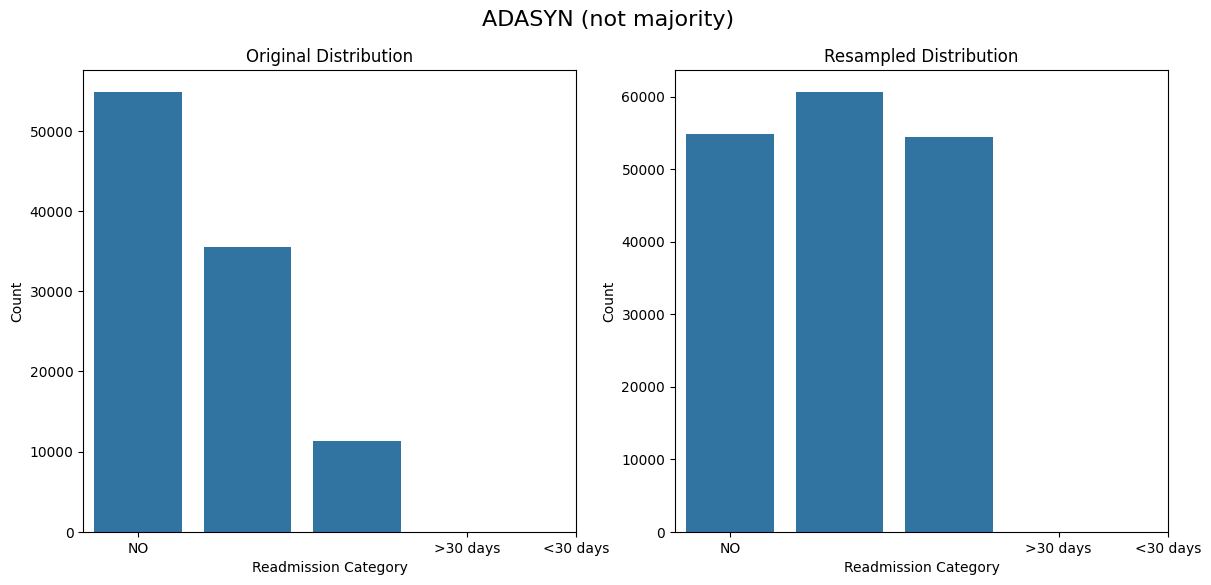

In [54]:
plot_class_distribution(y, y_asyn, "ADASYN (not majority)")

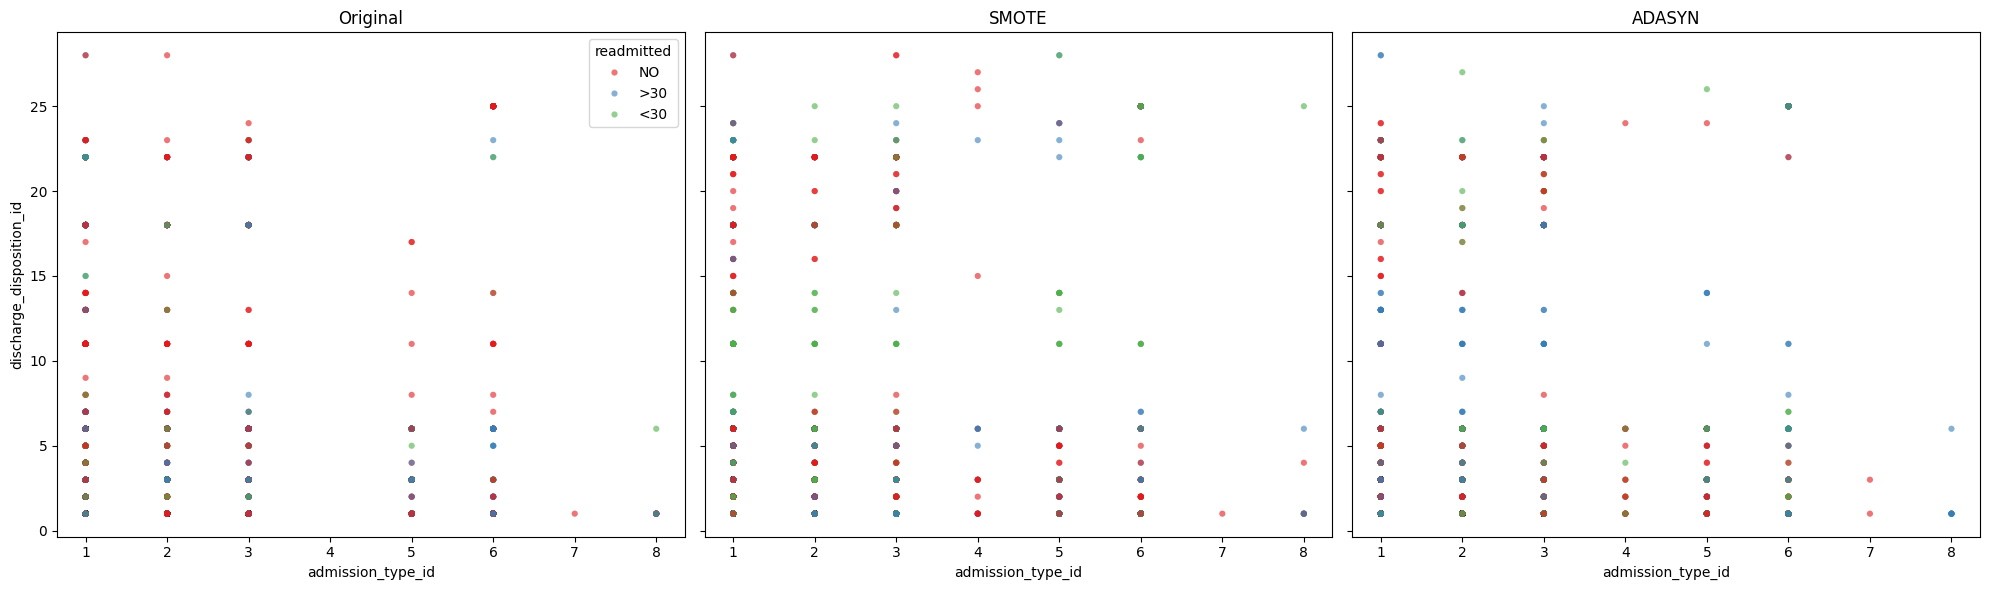

In [56]:
# Scatter plot original vs SMOTE vs ADASYN using the first two features
feature_x, feature_y = X.columns[:2]

def scatter_sample(X_data, y_data, label, ax, max_points=5000):
    df_plot = X_data.iloc[:, :2].copy()
    df_plot['readmitted'] = y_data.values
    if len(df_plot) > max_points:
        df_plot = df_plot.sample(n=max_points, random_state=1)
    sns.scatterplot(
        data=df_plot,
        x=feature_x,
        y=feature_y,
        hue='readmitted',
        palette='Set1',
        alpha=0.6,
        s=20,
        edgecolor='none',
        ax=ax,
        legend=(label == 'Original')
    )
    ax.set_title(label)
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)
scatter_sample(X, y, 'Original', axes[0])
scatter_sample(X_sm, y_sm, 'SMOTE', axes[1])
scatter_sample(X_asyn, y_asyn, 'ADASYN', axes[2])
plt.tight_layout()
plt.show()

In [ ]:
# Run ADASYN with the default automatic sampling strategy to compare it with the explicit setup above.
adasyn = ADASYN(sampling_strategy='auto', random_state=1)
X_asyn, y_asyn = adasyn.fit_resample(X, y)
print("Original distribution:", Counter(y))
print("ADASYN distribution:", Counter(y_asyn))
print("ADASYN feature distribution:", Counter(X_asyn))